# Métodos de Interpolação

## FOrma de Lagrange

In [2]:
import numpy as np
import matplotlib.pyplot as plt

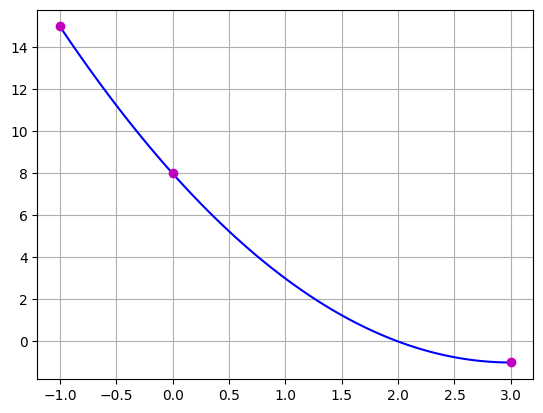

In [14]:
xi = np.array([-1, 0, 3])
yi = np.array([15, 8, -1])

n = len(xi)
n_pontos = 100 #numero de pontos da malha
x = np.linspace(xi[0], xi[n - 1], n_pontos)

L = np.ones((n, n_pontos))

for i in range(n):
    for j in range(n):
        if i != j:
            L[i, :] *= ((x - xi[j]) / (xi[i] - xi[j]))

y = yi @ L

plt.plot(x, y, "b-")
plt.plot(xi, yi, "mo")
plt.grid()

plt.show()

## Método Newton-Gregory

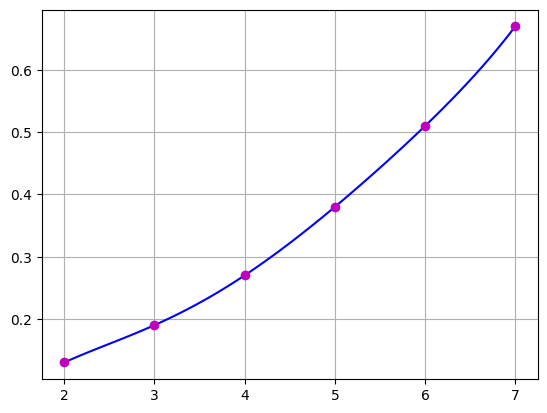

In [35]:
xi = np.array([2, 3, 4, 5, 6, 7])
yi = np.array([0.13, 0.19, 0.27, 0.38, 0.51, 0.67])

n = len(xi)
n_pontos = 100 #numero de pontos da malha
x = np.linspace(xi[0], xi[n - 1], n_pontos)

D = np.zeros((n, n))

D[:, 0] = yi
for j in range(1, n):
    for i in range(j, n):
        D[i, j] = (D[i, j - 1] - D[i - 1, j - 1]) / (xi[i] - xi[i - j])

c = np.diag(D)
y = np.ones(n_pontos) * c[0]
xv = np.ones(n_pontos)

for j in range(1, n):
    xv *= (x - xi[j - 1])
    y += c[j] * xv

x_v = 4.5
y_v = c[0]
xv_v = 1

for j in range(1, n):
    xv_v *= (x_v - xi[j - 1])
    y_v *= c[j] * xv_v

plt.plot(x, y, "b-")
plt.plot(xi, yi, "mo")
plt.grid()

plt.show()

## Método Splines

/tmp/ipykernel_893/2022748496.py:44: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y[k] = a[idx] + b[idx] * t + c[idx] * t ** 2 + d[idx] * t ** 3


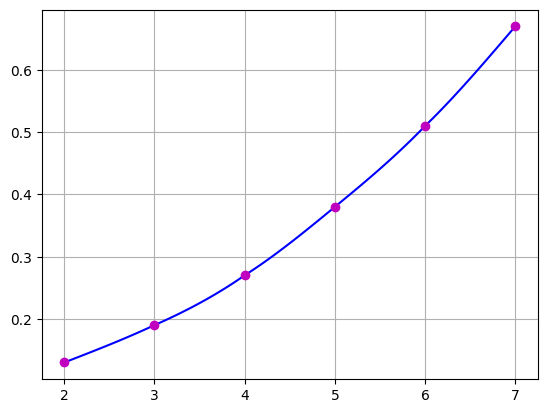

In [40]:
xi = np.array([2, 3, 4, 5, 6, 7])
yi = np.array([0.13, 0.19, 0.27, 0.38, 0.51, 0.67])

n = len(xi)
n_pontos = 100 #numero de pontos da malha
x = np.linspace(xi[0], xi[n - 1], n_pontos)

m = n - 1 #subintervalos
h = np.zeros(n - 1)

for i in range(n - 1):
    h[i] = xi[i + 1] - xi[i]

a = yi
A = np.zeros((n, n))
r = np.zeros((n, 1))

A[0, 0] = A[n - 1, n - 1] = 1

for j in range(1, n - 1):
    A[j, j - 1] = h[j - 1]
    A[j, j] = 2 * h[j - 1] + h[j]
    A[j, j + 1] = h[j]
    r[j] = 3 * ((a[j + 1] - a[j]) / h[j] - (a[j] - a[j - 1]) / h[j - 1])

c = np.linalg.solve(A, r)

d = np.zeros((m, 1))
b = np.zeros((m, 1))

for j in range(m):
    d[j] = (c[j + 1] - c[j]) / (3 * h[j])
    b[j] = (a[j + 1] - a[j]) / h[j] - h[j] / 3 * (2 * c[j] + c[j + 1])

y = np.zeros(n_pontos)

for k in range(n_pontos):
    idx = m
    for j in range(m):
        if x[k] <= xi[j + 1]:
            idx = j
            break
    t = x[k] - xi[idx]
    y[k] = a[idx] + b[idx] * t + c[idx] * t ** 2 + d[idx] * t ** 3

plt.plot(x, y, "b-")
plt.plot(xi, yi, "mo")
plt.grid()

plt.show()